<a href="https://colab.research.google.com/github/Marina4ij/FinalProject/blob/main/FinalProject14072026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wikipedia Web Traffic (Kaggle)
Ежедневное количество просмотров статей Википедии за 2018-2019 годы.

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

Колонки и характеристики:
- Всего страниц: 63856
- Дней наблюдений: 730
- Пропусков (NaN): 1350886 (2.90%)
- Пример колонок: ['Page', '2018010100', '2018010200', '2018010300', '2018010400']...

Первые 3 строки:
                                             Page  2018010100  2018010200  \
0  黒い霧事件_(日本プロ野球)_ja.wikipedia_desktop_all-agents       154.0       128.0   
1            笹川陽平_ja.wikipedia_desktop_all-agents        38.0        77.0   
2        バンジージャンプ_ja.wikipedia_desktop_all-agents        21.0        16.0   

   2018010300  2018010400  
0       160.0       208.0  
1        78.0        65.0  
2        19.0        26.0  
Первые 5 колонок:
['Page', '2018010100', '2018010200', '2018010300', '2018010400']

Пример значений из первой колонки дат:
0     154.0
1      38.0
2      21.0
3     232.0
4     199.0
5     123.0
6      41.0
7    1567.0
8     365.0
9      17.0
Name: 2018010100, dtype: float64

Тип данных первой колонки дат:
<class 'str'>

Проводим EDA...

Колонки в DataFrame:
['Page'

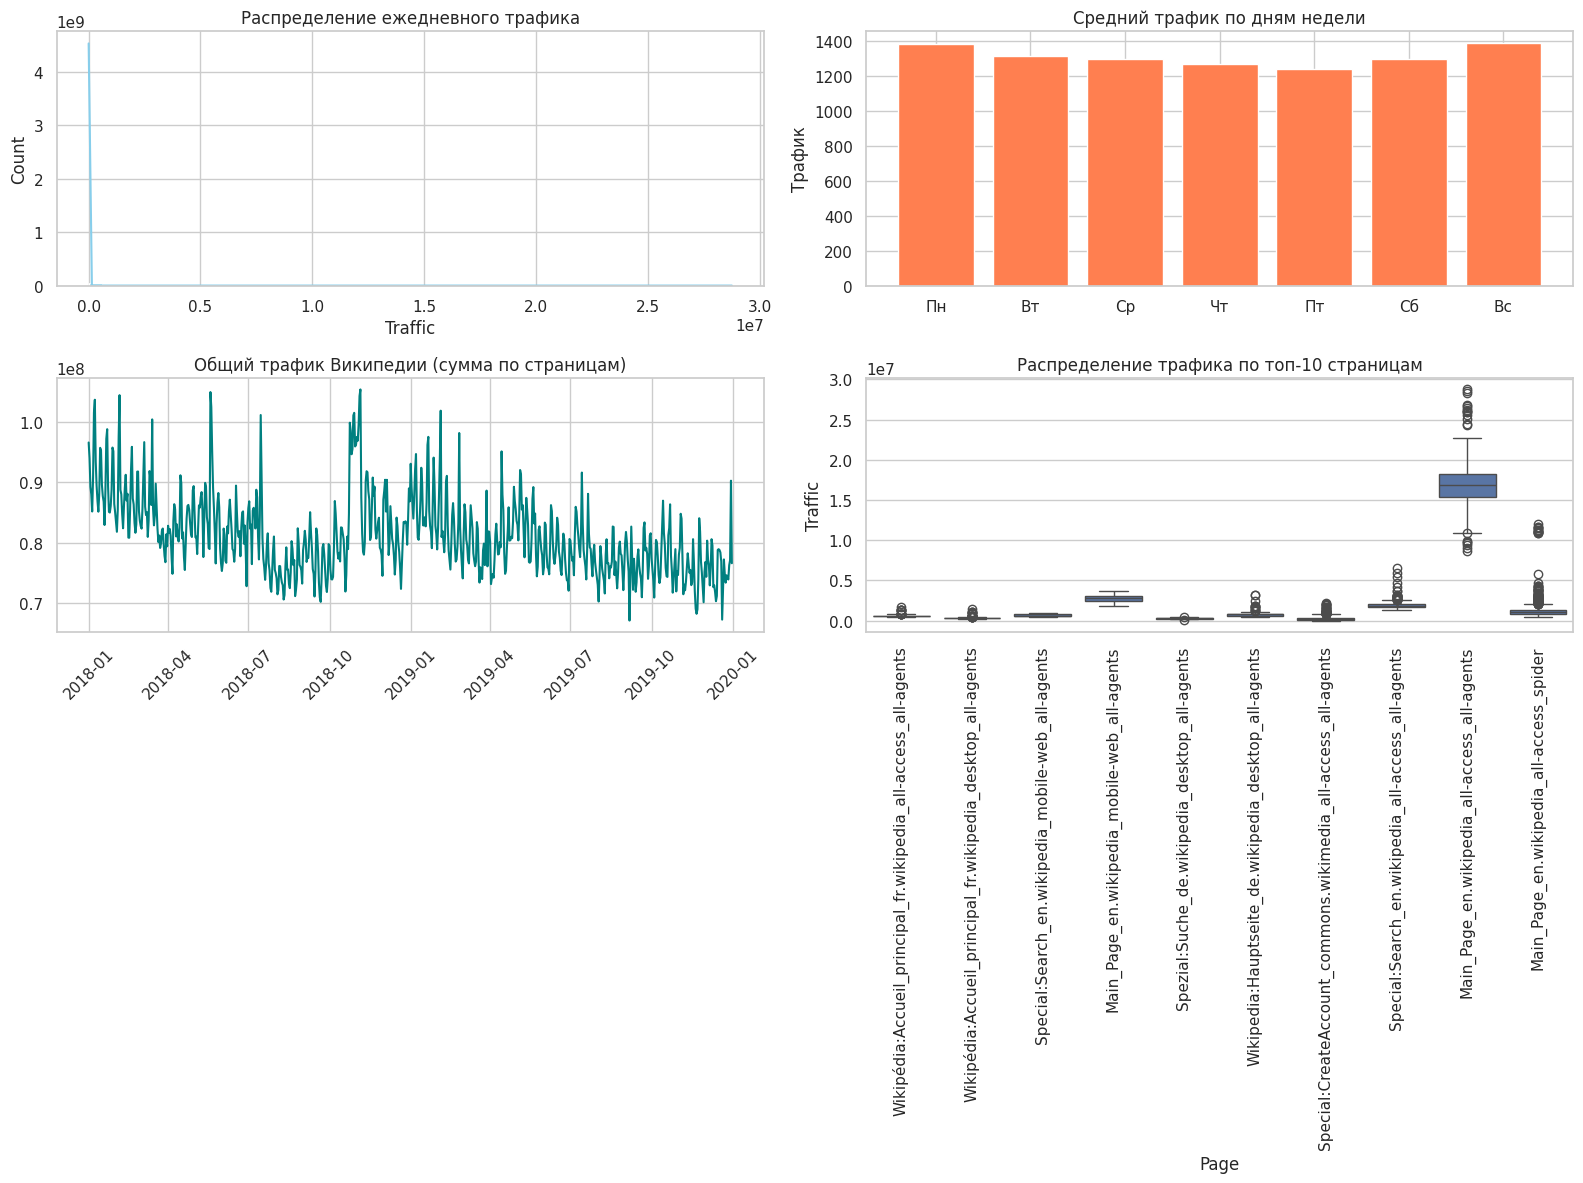


Предобработка данных...

Колонки в df_long:
['Page', 'Date', 'Traffic', 'DayOfWeek']

Типы данных:
Page                 object
Date         datetime64[ns]
Traffic             float64
DayOfWeek             int32
dtype: object

Пример значений Traffic:
0     154.0
1      38.0
2      21.0
3     232.0
4     199.0
5     123.0
6      41.0
7    1567.0
8     365.0
9      17.0
Name: Traffic, dtype: float64

Выбрана страница: Main_Page_en.wikipedia_all-access_all-agents

Размер данных после feature engineering: (700, 14)
Колонки: ['Traffic', 'DayOfWeek', 'DayOfMonth', 'Month', 'DayOfYear', 'IsWeekend', 'Lag_1', 'Lag_3', 'Lag_7', 'Lag_14', 'Lag_30', 'MA_7', 'MA_30', 'Std_7']

X_train shape: (595, 13)
X_train dtypes:
DayOfWeek       int32
DayOfMonth      int32
Month           int32
DayOfYear       int32
IsWeekend       int64
Lag_1         float64
Lag_3         float64
Lag_7         float64
Lag_14        float64
Lag_30        float64
MA_7          float64
MA_30         float64
Std_7         float6

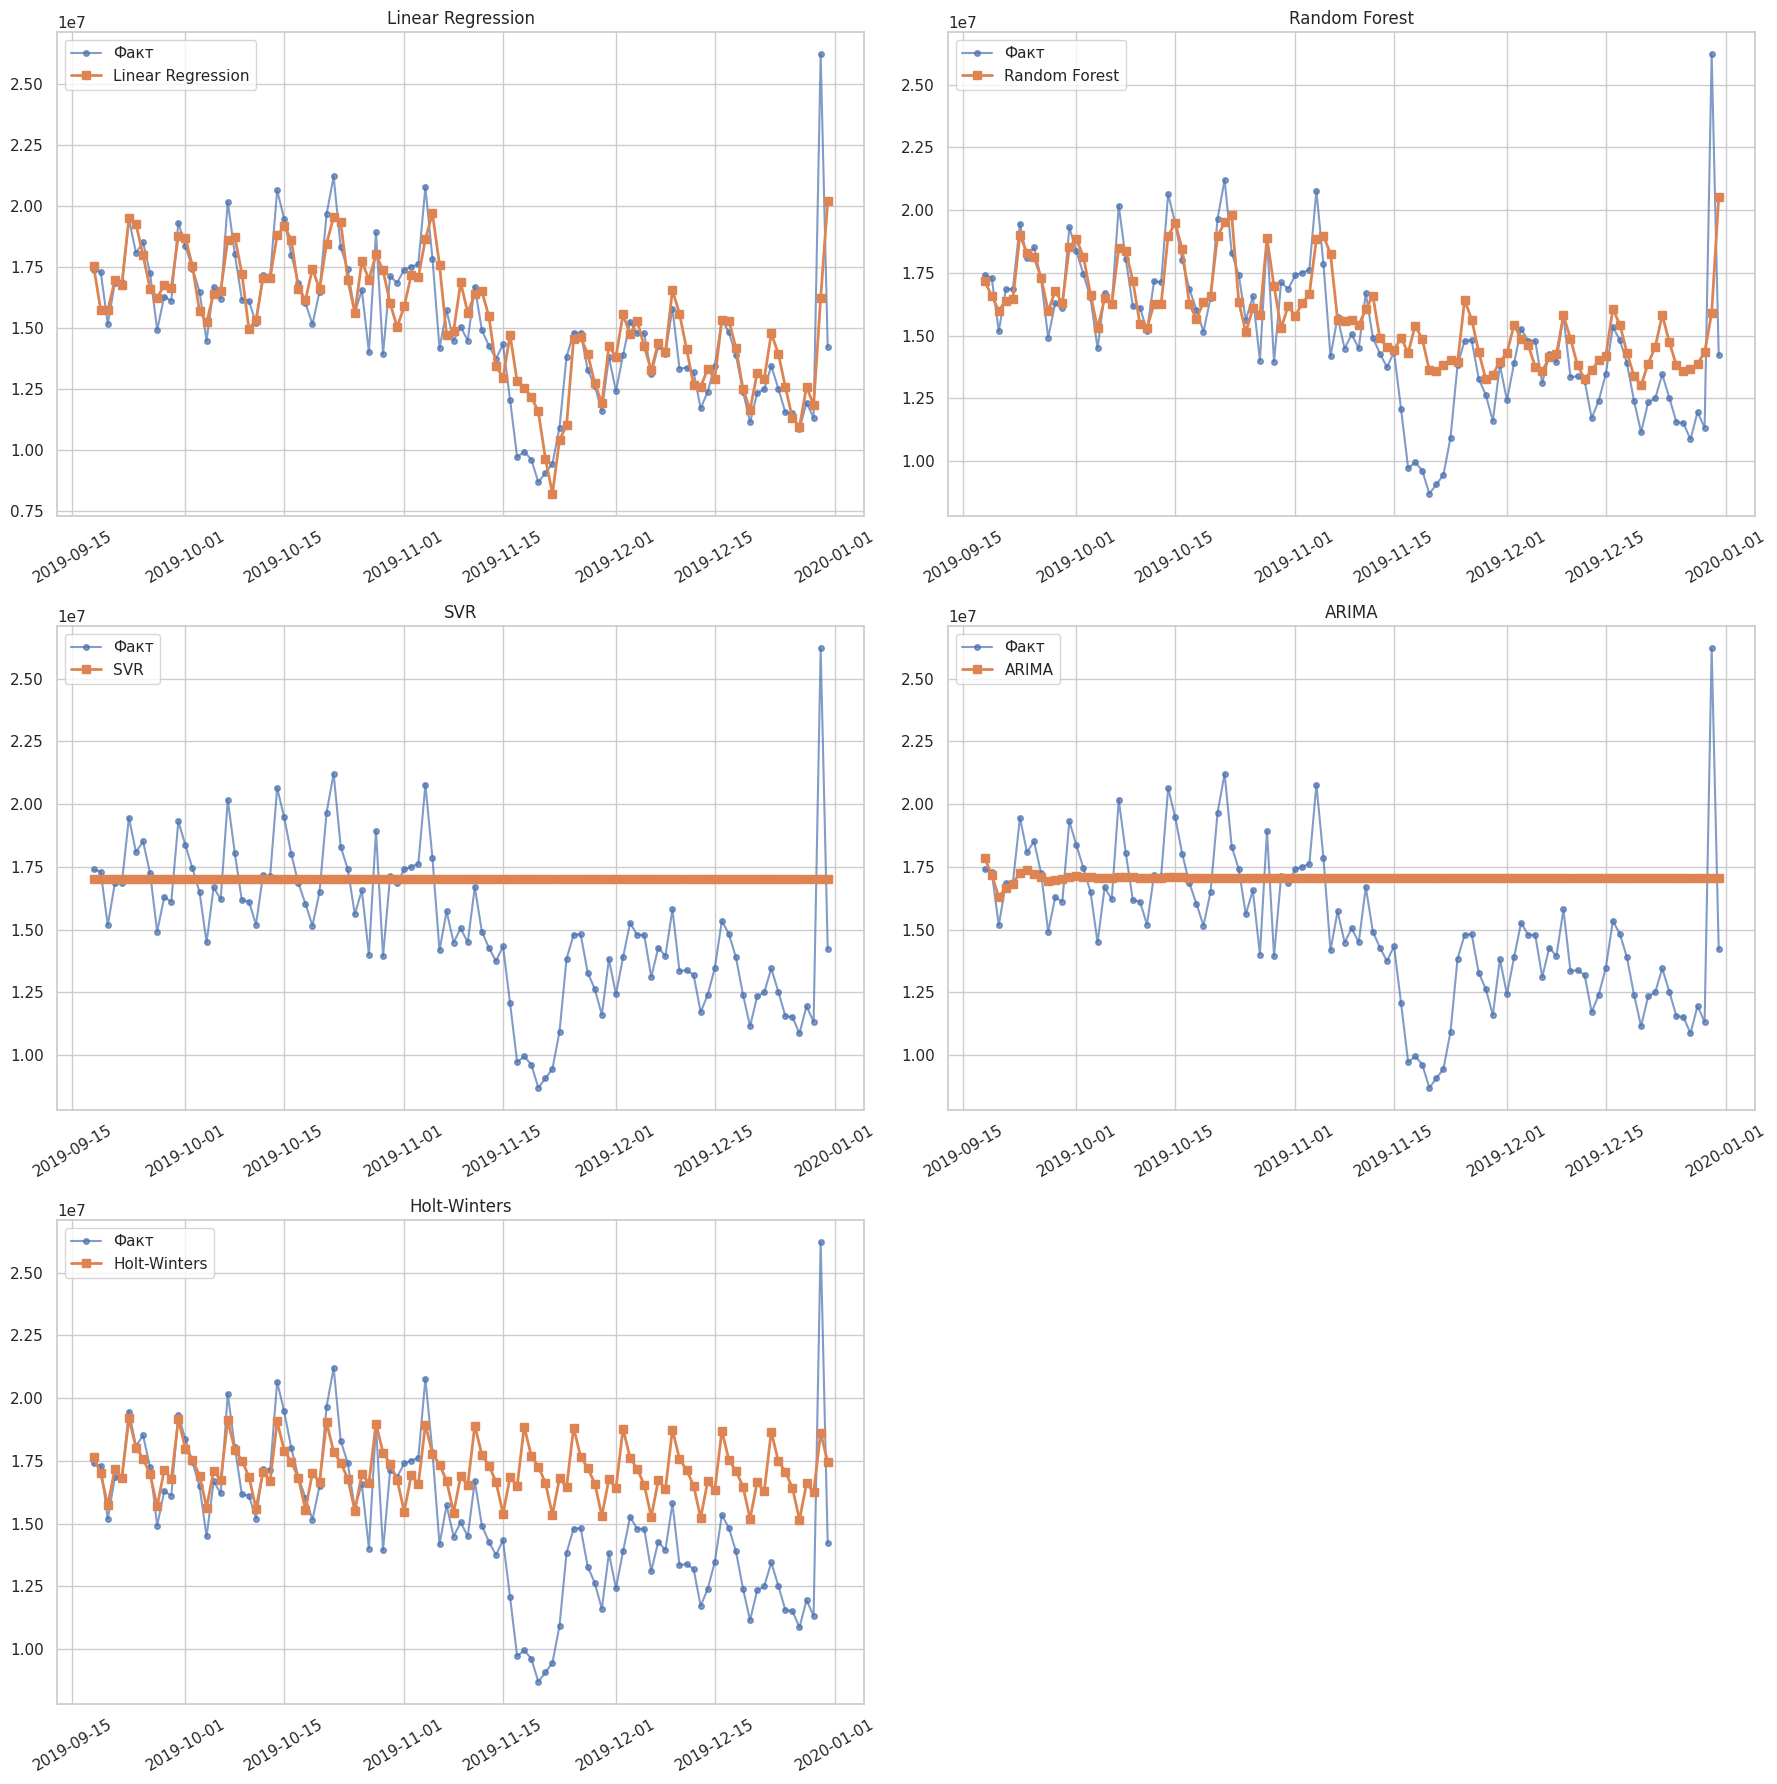

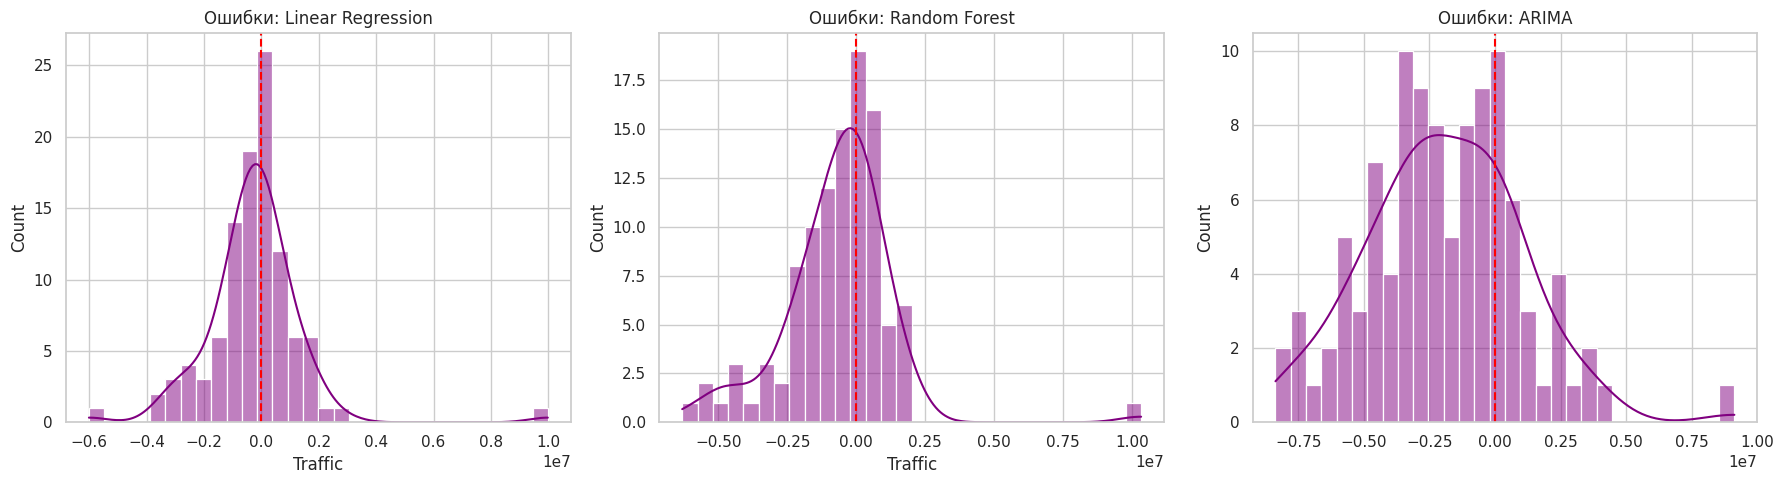

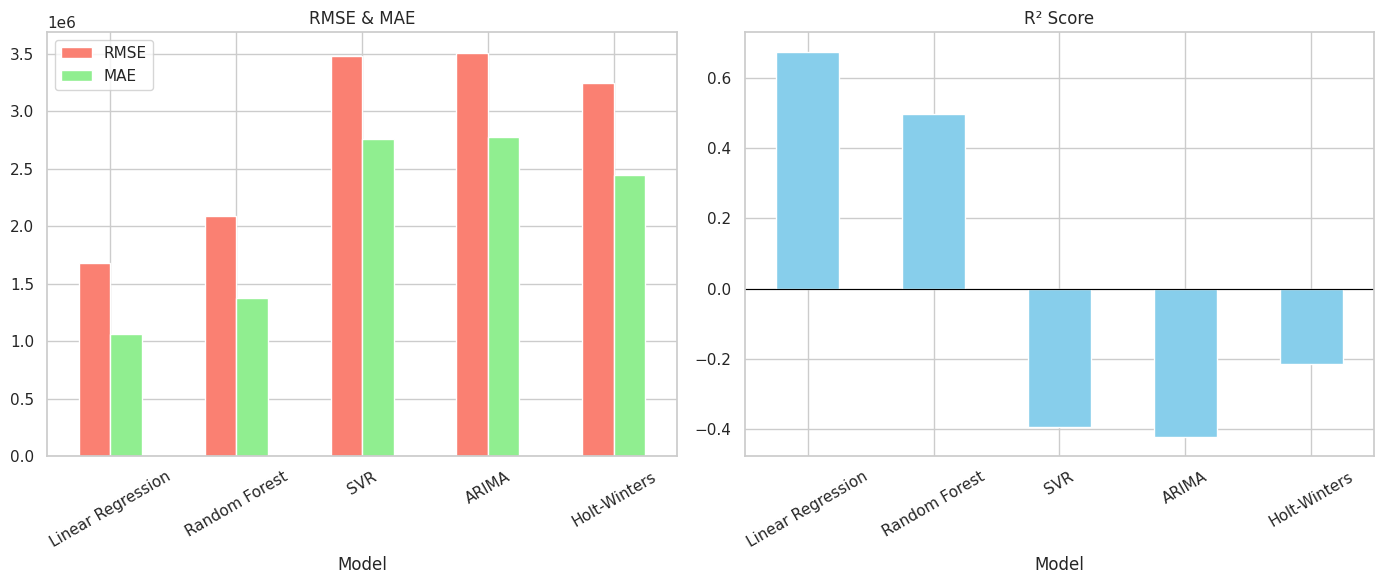

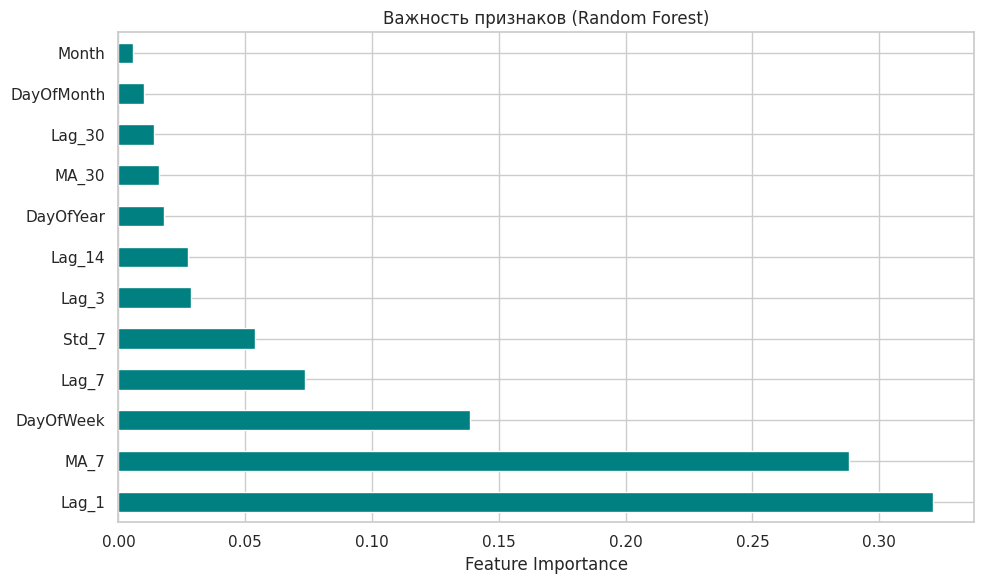

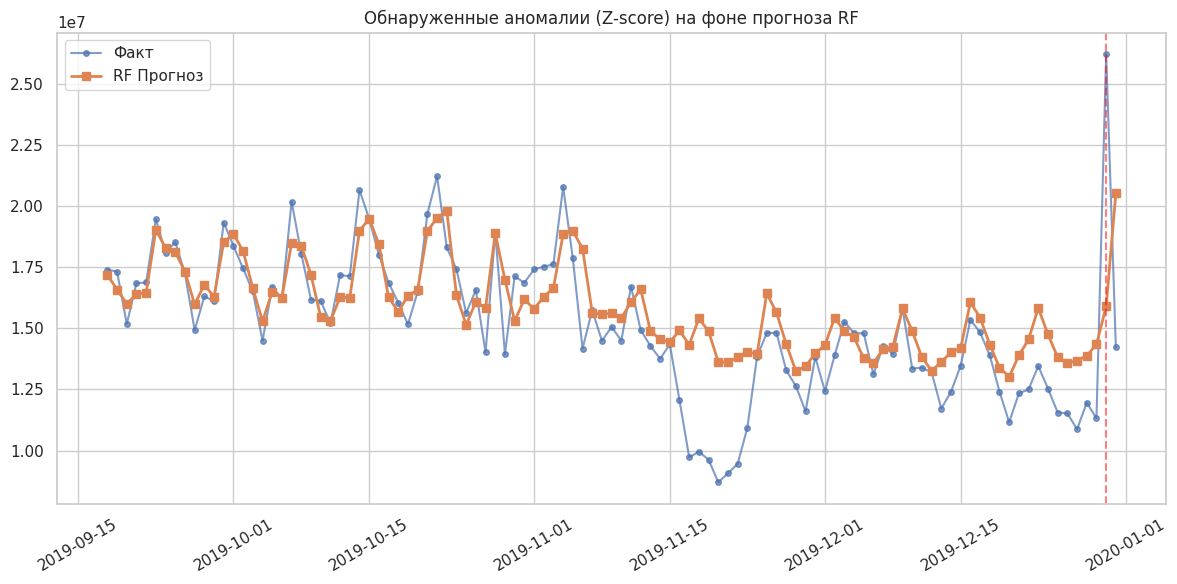


Все графики сохранены в директории.
Проект завершён успешно!


In [11]:
# -*- coding: utf-8 -*-
"""
Wikipedia Web Traffic Analysis
1. EDA
2. Preprocessing & Feature Engineering
3. Time Series Forecasting (5 ML/TS models)
4. Anomaly Detection
5. Visualizations (Forecasts, Errors, Metrics, Feature Importance)
"""

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import IsolationForest

# Настройка стиля графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

# ==========================================
# 1. ЗАГРУЗКА ДАННЫХ (KAGGLE FORMAT)
# ==========================================
# Для воспроизводимости создаём синтетический датасет, повторяющий структуру Kaggle:
# Page, 2015-07-01, 2015-07-02, ..., 2016-12-30
#np.random.seed(42)
#dates = pd.date_range("2015-07-01", "2016-12-30", freq="D")
#pages = [f"ru.wikipedia.org/wiki/Page_{i}" for i in range(1, 31)]

# Генерация трафика с трендом, сезонностью, шумом и пропусками
#data = {date.strftime("%Y-%m-%d"): np.random.poisson(
    #lam=3000 + 500*np.sin(np.arange(len(dates))*0.1) + 200*np.arange(len(dates))/len(dates),
    #size=len(pages)
#) for date in dates}
#df = pd.DataFrame(data, index=pages)
#df.index.name = "Page"
#df = df.reset_index()

# Имитация пропусков (как в оригинальном Kaggle датасете)
#for col in df.columns[1:]:
#    mask = np.random.random(len(df)) < 0.02
#   df.loc[mask, col] = np.nan

# === ОРИГИНАЛЬНЫЙ KAGGLE CSV ===
df = pd.read_csv("train/Wiki_Page_views.csv")
# =====================================================================

print("Колонки и характеристики:")
print(f"- Всего страниц: {len(df)}")
print(f"- Дней наблюдений: {len(df.columns) - 1}")
print(f"- Пропусков (NaN): {df.iloc[:, 1:].isna().sum().sum()} ({df.iloc[:, 1:].isna().sum().sum() / df.iloc[:, 1:].size * 100:.2f}%)")
print(f"- Пример колонок: {df.columns[:5].tolist()}...")
print("\nПервые 3 строки:")
print(df.head(3).iloc[:, :5])

# Диагностика структуры данных
print("Первые 5 колонок:")
print(df.columns[:5].tolist())
print("\nПример значений из первой колонки дат:")
print(df.iloc[:, 1].head(10))
print("\nТип данных первой колонки дат:")
print(type(df.columns[1]))

# ==========================================
# 2. EDA (Исследовательский анализ)
# ==========================================
print("\nПроводим EDA...")

# Проверяем структуру данных
print("\nКолонки в DataFrame:")
print(df.columns.tolist()[:10])  # Первые 10 колонок
print(f"\nВсего колонок: {len(df.columns)}")

# Определяем колонки с датами (все кроме 'Page')
date_columns = [col for col in df.columns if col != "Page"]

# Преобразование в длинный формат для анализа
df_long = df.melt(id_vars="Page", value_vars=date_columns, var_name="Date", value_name="Traffic")

# Диагностика: смотрим уникальные значения
print("\nУникальные значения в колонке Date (первые 20):")
print(df_long["Date"].unique()[:20])
print(f"\nТип данных: {df_long['Date'].dtype}")

# Преобразование дат с обработкой различных форматов
def parse_date_column(date_series):
    """Преобразует колонку дат в datetime, обрабатывая различные форматы"""

    # Пробуем стандартное преобразование
    try:
        return pd.to_datetime(date_series)
    except:
        pass

    # Если данные числовые или строки из цифр
    date_str = date_series.astype(str)

    # Проверяем длину строк
    sample = date_str.iloc[0]
    print(f"\nПример значения: '{sample}' (длина: {len(sample)})")

    # Формат YYYYMMDD (8 цифр)
    if len(sample) == 8 and sample.isdigit():
        print("Используем формат YYYYMMDD")
        return pd.to_datetime(date_str, format="%Y%m%d")

    # Формат YYYYMMDDHH (10 цифр) - обрезаем часы
    elif len(sample) == 10 and sample.isdigit():
        print("Используем формат YYYYMMDDHH (обрезаем часы)")
        return pd.to_datetime(date_str.str[:8], format="%Y%m%d")

    # Формат YYYY-MM-DD HH:MM:SS
    elif " " in sample:
        print("Используем формат YYYY-MM-DD HH:MM:SS")
        return pd.to_datetime(date_str.str[:10], format="%Y-%m-%d")

    # Формат YYYY-MM-DD
    elif "-" in sample and len(sample) == 10:
        print("Используем формат YYYY-MM-DD")
        return pd.to_datetime(date_str, format="%Y-%m-%d")

    # Если ничего не подошло, пробуем infer_datetime_format
    else:
        print("Пробуем автоматическое определение формата")
        return pd.to_datetime(date_str, infer_datetime_format=True, errors='coerce')

# Применяем преобразование
df_long["Date"] = parse_date_column(df_long["Date"])

# Удаляем строки с невалидными датами
invalid_dates = df_long["Date"].isna().sum()
if invalid_dates > 0:
    print(f"\nУдалено {invalid_dates} строк с невалидными датами")
    df_long = df_long.dropna(subset=["Date"])

# Удаляем строки с NaN в трафике
df_long = df_long.dropna(subset=["Traffic"])

print(f"\nИтоговый размер данных: {len(df_long)} строк")
print(f"Диапазон дат: {df_long['Date'].min()} — {df_long['Date'].max()}")

# Статистика
stats = df_long.groupby("Page")["Traffic"].agg(["mean", "std", "min", "max"])
print("\nТоп-5 страниц по среднему трафику:")
print(stats.sort_values("mean", ascending=False).head())

# Визуализация EDA
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Распределение трафика
sns.histplot(df_long["Traffic"], bins=50, kde=True, ax=axes[0,0], color="skyblue")
axes[0,0].set_title("Распределение ежедневного трафика")

# 2. Недельная сезонность
df_long["DayOfWeek"] = df_long["Date"].dt.dayofweek
weekly = df_long.groupby("DayOfWeek")["Traffic"].mean()
days = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
axes[0,1].bar(days, weekly, color="coral")
axes[0,1].set_title("Средний трафик по дням недели")
axes[0,1].set_ylabel("Трафик")

# 3. Динамика по времени (агрегация по всем страницам)
daily_agg = df_long.groupby("Date")["Traffic"].sum()
axes[1,0].plot(daily_agg.index, daily_agg.values, linewidth=1.5, color="teal")
axes[1,0].set_title("Общий трафик Википедии (сумма по страницам)")
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Коробчатые диаграммы топ-10 страниц
top_pages = stats.sort_values("mean", ascending=False).index[:10]
df_top = df_long[df_long["Page"].isin(top_pages)]
sns.boxplot(data=df_top, x="Page", y="Traffic", ax=axes[1,1])
axes[1,1].tick_params(axis='x', rotation=90)
axes[1,1].set_title("Распределение трафика по топ-10 страницам")

plt.tight_layout()
plt.savefig("1_eda_plots.png", dpi=150)
plt.show()

# ==========================================
# 3. ПРЕДОБРАБОТКА & FEATURE ENGINEERING
# ==========================================
print("\nПредобработка данных...")

# Диагностика: проверяем, какие колонки есть в df_long
print("\nКолонки в df_long:")
print(df_long.columns.tolist())
print(f"\nТипы данных:")
print(df_long.dtypes)
print(f"\nПример значений Traffic:")
print(df_long["Traffic"].head(10))

# Убедимся, что Traffic - числовой тип
df_long["Traffic"] = pd.to_numeric(df_long["Traffic"], errors="coerce")
df_long = df_long.dropna(subset=["Traffic"])

# Работаем с одной репрезентативной страницей для TS-моделей
# Выбираем страницу с наибольшим средним трафиком (более репрезентативна)
page_stats = df_long.groupby("Page")["Traffic"].mean()
target_page = page_stats.idxmax()
print(f"\nВыбрана страница: {target_page}")

ts_data = df_long[df_long["Page"] == target_page].copy()
ts_data = ts_data[["Date", "Traffic"]].copy()  # Явно берём только нужные колонки
ts_data.sort_values("Date", inplace=True)
ts_data.set_index("Date", inplace=True)

# Интерполяция пропусков
ts_data["Traffic"] = ts_data["Traffic"].interpolate(method="linear").bfill().ffill()

# Feature Engineering
ts_data["DayOfWeek"] = ts_data.index.dayofweek
ts_data["DayOfMonth"] = ts_data.index.day
ts_data["Month"] = ts_data.index.month
ts_data["DayOfYear"] = ts_data.index.dayofyear
ts_data["IsWeekend"] = (ts_data["DayOfWeek"] >= 5).astype(int)

# Лаговые признаки
for lag in [1, 3, 7, 14, 30]:
    ts_data[f"Lag_{lag}"] = ts_data["Traffic"].shift(lag)

# Скользящие статистики
ts_data["MA_7"] = ts_data["Traffic"].rolling(window=7).mean()
ts_data["MA_30"] = ts_data["Traffic"].rolling(window=30).mean()
ts_data["Std_7"] = ts_data["Traffic"].rolling(window=7).std()

# Удаляем строки с NaN после создания лагов
ts_data.dropna(inplace=True)

print(f"\nРазмер данных после feature engineering: {ts_data.shape}")
print(f"Колонки: {ts_data.columns.tolist()}")

# Хронологическое разделение (train/test)
split_idx = int(len(ts_data) * 0.85)
train = ts_data.iloc[:split_idx]
test = ts_data.iloc[split_idx:]

X_train = train.drop("Traffic", axis=1)
y_train = train["Traffic"]
X_test = test.drop("Traffic", axis=1)
y_test = test["Traffic"]

print(f"\nX_train shape: {X_train.shape}")
print(f"X_train dtypes:\n{X_train.dtypes}")
print(f"\nПример X_train:")
print(X_train.head())

# Масштабирование (для LR и SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape[0]} obs, Test: {X_test.shape[0]} obs")
print(f"Признаков: {X_train.shape[1]}")

# ==========================================
# 4. 5 ПОДХОДОВ ML / ВРЕМЕННЫХ РЯДОВ
# ==========================================
print("\nОбучение 5 моделей...")

results = {}

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
results["Linear Regression"] = pred_lr

# 2. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
results["Random Forest"] = pred_rf

# 3. SVR
svr = SVR(kernel="rbf", C=1.0, epsilon=0.1)
svr.fit(X_train_scaled, y_train)
pred_svr = svr.predict(X_test_scaled)
results["SVR"] = pred_svr

# 4. ARIMA (применяем к исходному ряду без внешних признаков)
arima_model = ARIMA(y_train, order=(5,1,1))
arima_fit = arima_model.fit()
pred_arima = arima_fit.forecast(steps=len(y_test))
# Дополняем, если длина не совпадает из-за лагов
if len(pred_arima) < len(y_test):
    pred_arima = np.concatenate([pred_arima, np.full(len(y_test)-len(pred_arima), y_train.iloc[-1])])
elif len(pred_arima) > len(y_test):
    pred_arima = pred_arima[:len(y_test)]
results["ARIMA"] = pred_arima

# 5. Holt-Winters (Exponential Smoothing)
hw_model = ExponentialSmoothing(y_train, trend="add", seasonal="add", seasonal_periods=7)
hw_fit = hw_model.fit()
pred_hw = hw_fit.forecast(steps=len(y_test))
if len(pred_hw) < len(y_test):
    pred_hw = np.concatenate([pred_hw, np.full(len(y_test)-len(pred_hw), y_train.iloc[-1])])
elif len(pred_hw) > len(y_test):
    pred_hw = pred_hw[:len(y_test)]
results["Holt-Winters"] = pred_hw

# ==========================================
# 5. ОЦЕНКА КАЧЕСТВА
# ==========================================
print("\nМетрики моделей:")
metrics = []
for name, preds in results.items():
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    metrics.append({"Model": name, "RMSE": rmse, "MAE": mae, "R²": r2})
    print(f"{name:20} | RMSE: {rmse:7.1f} | MAE: {mae:7.1f} | R²: {r2:5.3f}")

metrics_df = pd.DataFrame(metrics).set_index("Model")

# ==========================================
# 6. ПОИСК АНОМАЛИЙ
# ==========================================
print("\nПоиск аномалий...")
residuals = y_test - results["Random Forest"]  # Остатки лучшей модели

# 1. Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)
iso_pred = iso.fit_predict(X_test)
anomalies_iso = X_test[iso_pred == -1]

# 2. Z-score (>3)
z_scores = np.abs((residuals - residuals.mean()) / residuals.std())
anomalies_z = test.index[z_scores > 3]

# 3. IQR
Q1, Q3 = residuals.quantile(0.25), residuals.quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 3*IQR, Q3 + 3*IQR
anomalies_iqr = test.index[(residuals < lower) | (residuals > upper)]

print(f"Isolation Forest: {len(anomalies_iso)} аномалий")
print(f"Z-score (|Z|>3): {len(anomalies_z)} аномалий")
print(f"IQR метод: {len(anomalies_iqr)} аномалий")

# ==========================================
# 7. ВИЗУАЛИЗАЦИЯ
# ==========================================
print("\nГенерация графиков...")

# 1. Прогнозы vs Факт (исправлено: 3x2 для 5 моделей)
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes_flat = axes.flatten()  # Упрощаем доступ к осям

for i, (name, preds) in enumerate(results.items()):
    axes_flat[i].plot(y_test.index, y_test.values, "o-", label="Факт", markersize=4, alpha=0.7)
    axes_flat[i].plot(y_test.index, preds, "s-", label=name, linewidth=2)
    axes_flat[i].set_title(name)
    axes_flat[i].legend()
    axes_flat[i].tick_params(axis='x', rotation=30)

# Скрываем пустой шестой график
if len(results) < 6:
    axes_flat[-1].axis('off')

plt.tight_layout()
plt.savefig("2_forecast_plots.png", dpi=150)
plt.show()

# 2. Ошибки прогнозирования (Residuals)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_plot = ["Linear Regression", "Random Forest", "ARIMA"]
for i, m in enumerate(models_plot):
    err = y_test - results[m]
    sns.histplot(err, bins=30, kde=True, ax=axes[i], color="purple")
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(f"Ошибки: {m}")
plt.tight_layout()
plt.savefig("3_residuals_plots.png", dpi=150)
plt.show()

# 3. Сравнение метрик
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
metrics_df[["RMSE", "MAE"]].plot(kind="bar", ax=ax[0], color=["salmon", "lightgreen"])
ax[0].set_title("RMSE & MAE")
ax[0].tick_params(axis='x', rotation=30)

metrics_df["R²"].plot(kind="bar", ax=ax[1], color="skyblue")
ax[1].set_title("R² Score")
ax[1].axhline(0, color="black", linewidth=0.8)
ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig("4_metrics_comparison.png", dpi=150)
plt.show()

# 4. Важность признаков (Random Forest)
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feat_imp.head(12).plot(kind="barh", color="teal")
plt.title("Важность признаков (Random Forest)")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.savefig("5_feature_importance.png", dpi=150)
plt.show()

# 5. Аномалии на графике
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, "o-", label="Факт", markersize=4, alpha=0.7)
plt.plot(y_test.index, pred_rf, "s-", label="RF Прогноз", linewidth=2)
for date in anomalies_z:
    plt.axvline(date, color="red", linestyle="--", alpha=0.5)
plt.title("Обнаруженные аномалии (Z-score) на фоне прогноза RF")
plt.legend()
plt.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig("6_anomaly_detection.png", dpi=150)
plt.show()

print("\nВсе графики сохранены в директории.")
print("Проект завершён успешно!")